In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [2]:
from autograd.engine import Value
from autograd.nn import MLP, Layer, Neuron

In [3]:
np.random.seed(42)
random.seed(42)

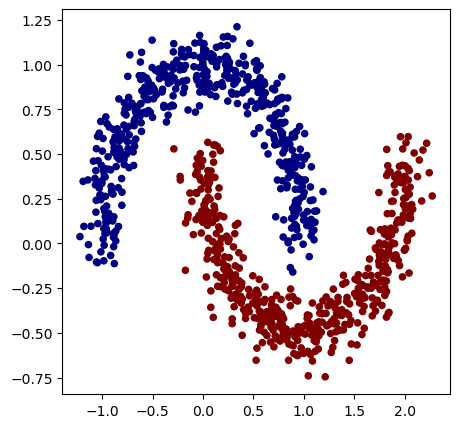

In [4]:
# make dataset
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.1)

y = y*2 - 1 # transform y into -1 or 1

# visualize
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [5]:
model = MLP(2, [16, 16, 1]) # 2 layer nueral network
print("number of parameters", len(model.paramaters()))

number of parameters 337


In [6]:
def loss(batch_size=None):
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]

    scores = list(map(model, inputs))

    # svm "max-margin" loss
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0/len(losses))
    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum(p*p for p in model.paramaters())
    total_loss = data_loss + reg_loss

    # accuracy 
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)


Value(data=0.7137937835915216, grad=0.0) 0.705


In [7]:
# optimization
for k in range(100):
    # foward 
    total_loss, acc = loss()

    # backward
    model.zero_grad()
    total_loss.backward()

    # update (sgd)
    lr = 0.01
    for p in model.paramaters():
        p.data -= lr * p.grad

    if k % 1 == 0:
        print(f"step {k} || loss {total_loss.data:.2f} || accuracy {acc*100:.2f}%")

step 0 || loss 0.71 || accuracy 70.50%
step 1 || loss 0.70 || accuracy 71.10%
step 2 || loss 0.67 || accuracy 73.90%
step 3 || loss 0.63 || accuracy 77.90%
step 4 || loss 0.57 || accuracy 78.90%
step 5 || loss 0.50 || accuracy 80.80%
step 6 || loss 0.44 || accuracy 81.40%
step 7 || loss 0.39 || accuracy 83.00%
step 8 || loss 0.38 || accuracy 83.90%
step 9 || loss 0.42 || accuracy 85.20%
step 10 || loss 0.46 || accuracy 82.90%
step 11 || loss 0.47 || accuracy 82.20%
step 12 || loss 0.43 || accuracy 83.40%
step 13 || loss 0.38 || accuracy 85.70%
step 14 || loss 0.35 || accuracy 85.50%
step 15 || loss 0.34 || accuracy 85.30%
step 16 || loss 0.34 || accuracy 85.00%
step 17 || loss 0.35 || accuracy 84.90%
step 18 || loss 0.36 || accuracy 84.50%
step 19 || loss 0.37 || accuracy 84.90%
step 20 || loss 0.37 || accuracy 85.30%
step 21 || loss 0.38 || accuracy 84.90%
step 22 || loss 0.39 || accuracy 84.80%
step 23 || loss 0.39 || accuracy 84.50%
step 24 || loss 0.39 || accuracy 84.80%
step 25 ||

(-1.7458205375887021, 2.004179462411298)

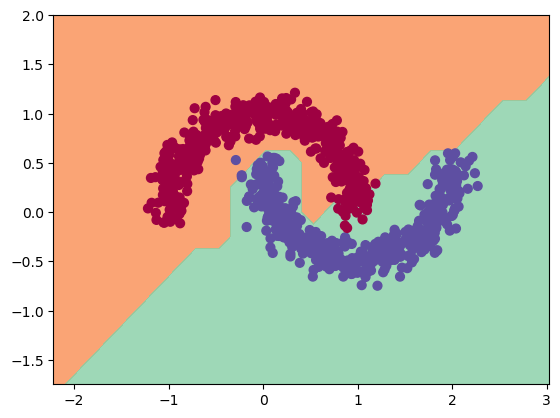

In [8]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

In [10]:
# test set
X, y = make_moons(n_samples=200, noise=0.1)

y = y*2 - 1 # transform y into -1 or 1

inputs = [list(map(Value, xrow)) for xrow in X]
scores = list(map(model, inputs))
accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(y, scores)]

print((sum(accuracy) / len(accuracy)) * 100)

97.5
